### 1. Cargando librerías

In [1]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import os
import platform
import torch
import ultralytics
import sys
import shutil
import subprocess

In [2]:
print("=" * 60)
print("ENTORNO DE EJECUCIÓN")
print("=" * 60)

print(f"Python:       {sys.version.split()[0]}")
print(f"Ejecutable:   {sys.executable}")
print(f"Sistema:      {platform.system()} {platform.release()}")

print("\n" + "=" * 60)
print("DEEP LEARNING")
print("=" * 60)

print(f"PyTorch:      {torch.__version__}")
print(f"Ultralytics:  {ultralytics.__version__}")
print(f"CUDA activa:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:          {torch.cuda.get_device_name(0)}")
    print(f"CUDA PyTorch: {torch.version.cuda}")

print("\n" + "=" * 60)
print("JUPYTER")
print("=" * 60)

print(f"Sesión Jupyter: {os.environ.get('JPY_SESSION_NAME', 'No identificada')}")

ENTORNO DE EJECUCIÓN
Python:       3.11.9
Ejecutable:   d:\MAESTRÍA EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL\Módulo VIIII - PROCESAMIENTO DE IMÁGENES Y VISIÓN COMPUTACIONAL\Proyecto Final\.venv\Scripts\python.exe
Sistema:      Windows 10

DEEP LEARNING
PyTorch:      2.13.0+cu126
Ultralytics:  8.4.118
CUDA activa:  True
GPU:          NVIDIA GeForce GTX 1050 Ti
CUDA PyTorch: 12.6

JUPYTER
Sesión Jupyter: No identificada


### 2. Cargando los pesos del modelo

In [3]:
modelo = YOLO(
    "runs/entrenamiento/"
    "yolo11n_vehiculos_v2_dominio_objetivo_seed42-2/"
    "weights/best.pt"
)

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [4]:
total_parametros = sum(
    p.numel() for p in modelo.model.parameters()
)

parametros_entrenables = sum(
    p.numel()
    for p in modelo.model.parameters()
    if p.requires_grad
)

print(f"Parámetros totales: {total_parametros:,}")
print(f"Parámetros entrenables: {parametros_entrenables:,}")

Parámetros totales: 2,591,010
Parámetros entrenables: 0


In [5]:
for nombre, parametro in modelo.model.named_parameters():
    print("Capa:", nombre)
    print("Forma:", parametro.shape)
    print("Primeros valores:")
    print(parametro.flatten()[:10])
    break

Capa: model.0.conv.weight
Forma: torch.Size([16, 3, 3, 3])
Primeros valores:
tensor([-0.1345, -0.0198,  0.1743, -0.3398, -0.0461,  0.3586, -0.2395, -0.0218,  0.2666, -0.1588])


In [6]:
print("Pesos cargados desde:")
print(modelo.ckpt_path)

print("\nResumen del modelo:")
modelo.info()

Pesos cargados desde:
runs\entrenamiento\yolo11n_vehiculos_v2_dominio_objetivo_seed42-2\weights\best.pt

Resumen del modelo:
YOLO11n summary: 182 layers, 2,591,010 parameters, 0 gradients, 6.5 GFLOPs


(182, 2591010, 0, 6.50496)

### 3. Mostrar las clases

In [7]:
modelo.names

{0: 'car', 1: 'threewheel', 2: 'bus', 3: 'truck', 4: 'motorbike', 5: 'van'}

### 4. Ejemplo correcto

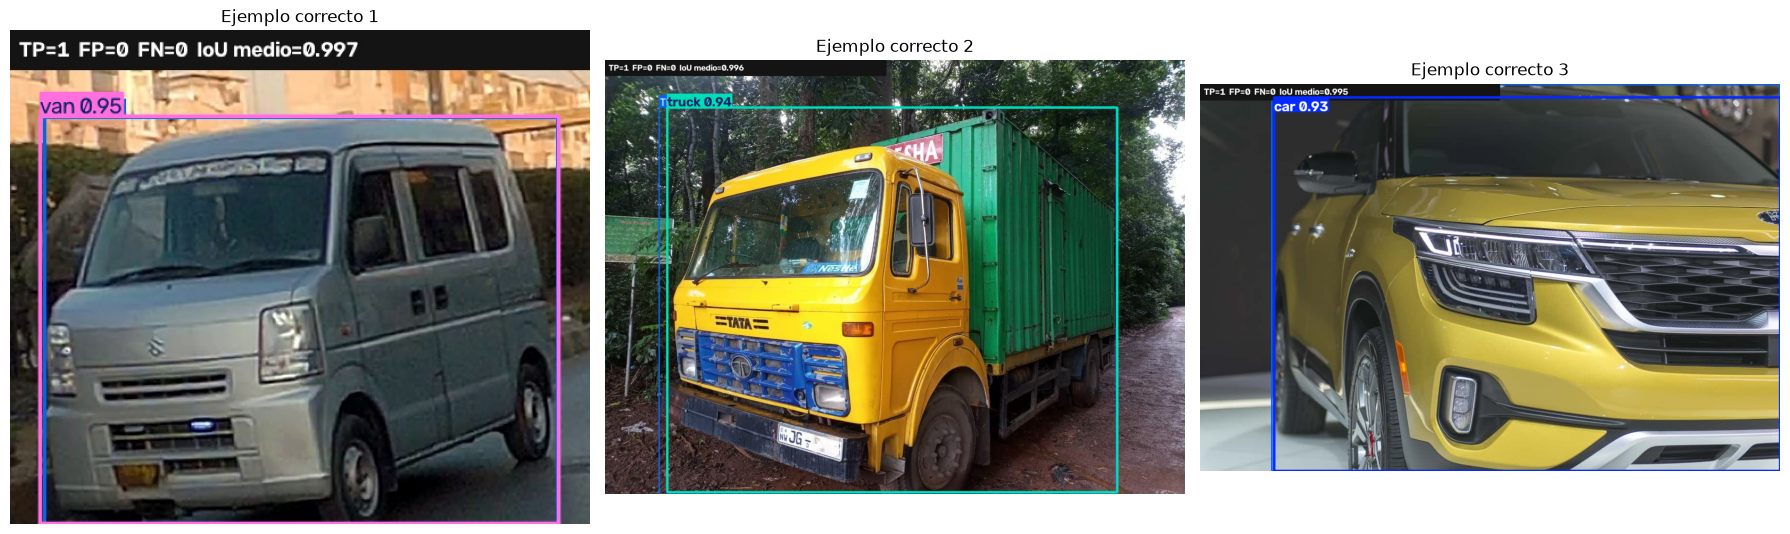

In [8]:
correctos = sorted(
    Path("resultados/evidencia_cualitativa/correctos").glob("*.jpg")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ruta in enumerate(correctos[:3]):
    resultado = modelo.predict(
        source=str(ruta),
        conf=0.35,
        verbose=False
    )[0]

    imagen = cv2.cvtColor(
        resultado.plot(),
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(imagen)
    axes[i].set_title(f"Ejemplo correcto {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 5. Ejemplo incorrecto

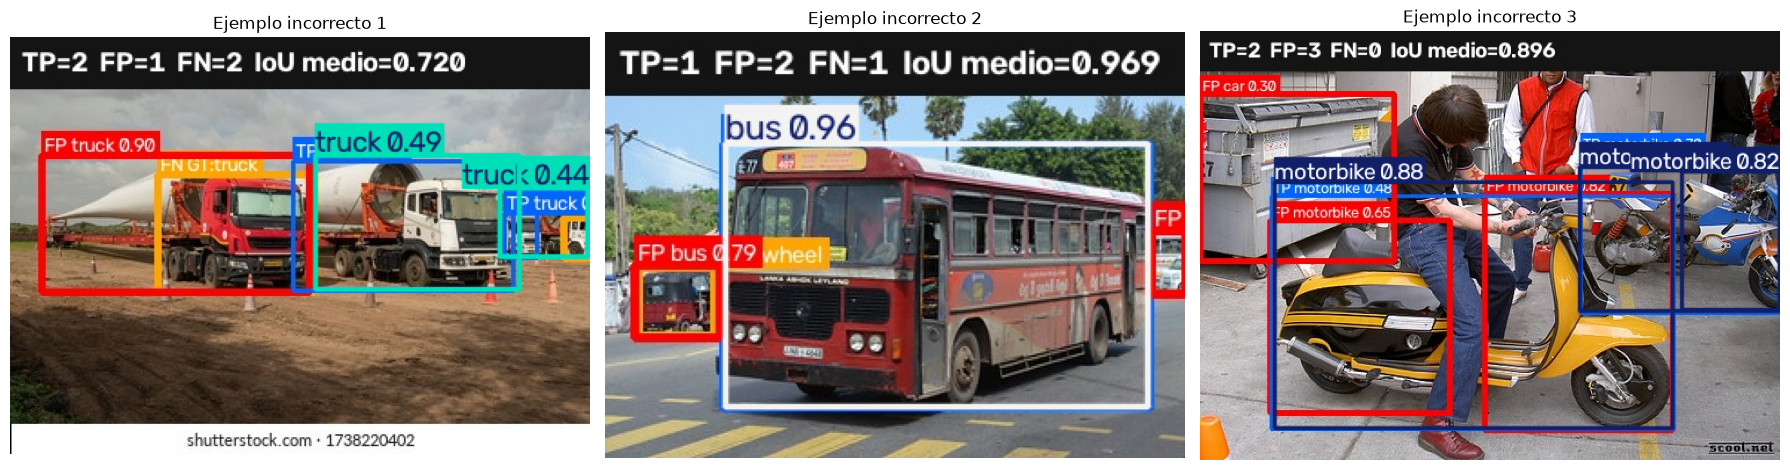

In [9]:
errores = sorted(
    Path("resultados/evidencia_cualitativa/errores").glob("*.jpg")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ruta in enumerate(errores[:3]):
    resultado = modelo.predict(
        source=str(ruta),
        conf=0.35,
        verbose=False
    )[0]

    imagen = cv2.cvtColor(
        resultado.plot(),
        cv2.COLOR_BGR2RGB
    )

    axes[i].imshow(imagen)
    axes[i].set_title(f"Ejemplo incorrecto {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 6. Demostración del sistema completo y en tiempo real

In [10]:
url_youtube = "https://www.youtube.com/watch?v=NfsyRx50gAI"

node_path = shutil.which("node")

print("Python del kernel:", sys.executable)
print("Node encontrado en:", node_path)

comando = [
    sys.executable, "-m", "yt_dlp",
    "--cookies-from-browser", "firefox",
    "--js-runtimes", f"node:{node_path}",
    "--remote-components", "ejs:github",
    "-f", "best[protocol^=m3u8][height<=720]/best[height<=720]/best",
    "--get-url",
    url_youtube
]

resultado = subprocess.run(
    comando,
    capture_output=True,
    text=True
)

print("Código de salida:", resultado.returncode)
print("\nSTDOUT:")
print(resultado.stdout)

print("\nSTDERR:")
print(resultado.stderr)

Python del kernel: d:\MAESTRÍA EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL\Módulo VIIII - PROCESAMIENTO DE IMÁGENES Y VISIÓN COMPUTACIONAL\Proyecto Final\.venv\Scripts\python.exe
Node encontrado en: C:\nvm4w\nodejs\node.EXE
Código de salida: 0

STDOUT:
https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1787213183/ei/H2GGavirOLz7-LAPmM3lwQQ/ip/179.238.29.38/id/NfsyRx50gAI.1/itag/95/source/yt_live_broadcast/requiressl/yes/ratebypass/yes/live/1/sgoap/gir%3Dyes%3Bitag%3D140/sgovp/gir%3Dyes%3Bitag%3D136/rqh/1/hls_chunk_host/rr1---sn-n25jxm-cncl.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/playlist_duration/30/manifest_duration/30/siu/1/bui/AR3QkAlJWLJI-h07qViR0KrVRrVQBpaApigqLpIVcXucagQKST8QdHO1fcm-9bswDvqmTxWA6g/spc/KBGBcoxkinvofGh8CrfV_EdBfXYcAAepDsx79Ec-bE9PC2Pl1dd_p9St2Q/vprv/1/ns/KhQDXI9KwB_9FMXsvwar6QEX/reg/0/playlist_type/DVR/initcwndbps/480000/met/1787191588,/mh/v1/mm/44/mn/sn-n25jxm-cncl/ms/lva/mv/m/mvi/1/pl/23/rms/lva,lva/dover/11/pacing/0/keepalive/yes/fexp/51565116,5194

In [11]:
camera_url = resultado.stdout.strip()

if not camera_url.startswith("https://"):
    raise RuntimeError("No se obtuvo una URL válida del stream.")

print("Stream obtenido correctamente.")
print("Longitud:", len(camera_url))

Stream obtenido correctamente.
Longitud: 1251


In [14]:
comando_demo = [
    sys.executable,
    "camara_tiempo_real.py",
    "--source", camera_url,
    "--traffic",
    "--model",
    "runs/entrenamiento/yolo11n_vehiculos_v2_dominio_objetivo_seed42-2/weights/best.pt",
    "--imgsz", "768",
    "--conf", "0.35",
    "--device", "0",
    "--events", "eventos_trafico.csv",
    "--sessions", "sesiones_aforo.csv"
]

subprocess.run(comando_demo)

CompletedProcess(args=['d:\\MAESTRÍA EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL\\Módulo VIIII - PROCESAMIENTO DE IMÁGENES Y VISIÓN COMPUTACIONAL\\Proyecto Final\\.venv\\Scripts\\python.exe', 'camara_tiempo_real.py', '--source', 'https://manifest.googlevideo.com/api/manifest/hls_playlist/expire/1787213183/ei/H2GGavirOLz7-LAPmM3lwQQ/ip/179.238.29.38/id/NfsyRx50gAI.1/itag/95/source/yt_live_broadcast/requiressl/yes/ratebypass/yes/live/1/sgoap/gir%3Dyes%3Bitag%3D140/sgovp/gir%3Dyes%3Bitag%3D136/rqh/1/hls_chunk_host/rr1---sn-n25jxm-cncl.googlevideo.com/xpc/EgVo2aDSNQ%3D%3D/playlist_duration/30/manifest_duration/30/siu/1/bui/AR3QkAlJWLJI-h07qViR0KrVRrVQBpaApigqLpIVcXucagQKST8QdHO1fcm-9bswDvqmTxWA6g/spc/KBGBcoxkinvofGh8CrfV_EdBfXYcAAepDsx79Ec-bE9PC2Pl1dd_p9St2Q/vprv/1/ns/KhQDXI9KwB_9FMXsvwar6QEX/reg/0/playlist_type/DVR/initcwndbps/480000/met/1787191588,/mh/v1/mm/44/mn/sn-n25jxm-cncl/ms/lva/mv/m/mvi/1/pl/23/rms/lva,lva/dover/11/pacing/0/keepalive/yes/fexp/51565116,51946838,51973818/n/3qQJ0vm

### 7. Resultado final del sistema

A partir de los eventos generados durante el aforo se calculan las métricas temporales de tráfico y una estimación preliminar del TPDA.

In [13]:
comando_tpda = [
    sys.executable,
    "src/calcular_tpda.py",
    "--events", "eventos_trafico.csv",
    "--sessions", "sesiones_aforo.csv",
    "--config", "config_tpda.json"
]

resultado_tpda = subprocess.run(
    comando_tpda,
    capture_output=True,
    text=True
)

print(resultado_tpda.stdout)

if resultado_tpda.stderr:
    print("\nERRORES:")
    print(resultado_tpda.stderr)


AFORO VEHICULAR
Sesion:    20260819_220638
Estacion:  UADE-01
Via:       Av. Independencia
Inicio:    2026-08-19T22:06:38.480000-04:00
Fin:       2026-08-19T22:07:23.983000-04:00
Duracion:  45 s (0.013 h)
Estado:    COMPLETADA
Vehiculos: 16

Composicion vehicular:
  auto            13 ( 81.25%)
  moto             3 ( 18.75%)

Distribucion direccional:
  A: 16 (100.00%)

METRICAS TEMPORALES
Tasa equivalente del periodo: 1280.0 veh/h
q15:                           -- (<15 min)
TH actual:                     -- (<60 min)

VHP PROXY HISTORICO
Maximo TH observado:          1240 veh/h
Sesion de referencia:          20260818_152202

TPDA PRELIMINAR
VHP proxy:                    1240 veh/h
k:                            0.080
Tipo de via de referencia:    suburbana

TPDA preliminar = VHP proxy / k
TPDA preliminar = 1240 / 0.080

TPDA PRELIMINAR: 15,500 veh/dia

IMPORTANTE: resultado estimado, no TPDA anual observado.
Nota: Valor de referencia metodologica. Requiere calibracion local para uso o